In [1]:
import os
import pandas as pd
import kagglehub
import os

print(os.listdir("/kaggle/input"))

path = '/kaggle/input/datasets/adityajanjiree/bone-cancer'
dataset_path = os.path.join(path, "BTXRD")

# path
images_path = os.path.join(dataset_path, "images")
excel_path = os.path.join(dataset_path, "dataset.xlsx")

# load data
df = pd.read_excel(excel_path)

print("Total data awal:", len(df))

# filter lower limb
df = df[df["lower limb"] == 1].copy()

print("Total data lower limb:", len(df))
print(df.head())

['datasets']
Total data awal: 3746
Total data lower limb: 2406
         image_id  center  age gender  hand  ulna  radius  humerus  foot  \
1  IMG000002.jpeg       1   12      M     0     0       0        0     0   
2  IMG000003.jpeg       1   12      M     0     0       0        0     0   
3  IMG000004.jpeg       1   52      M     0     0       0        0     1   
4  IMG000005.jpeg       1   52      M     0     0       0        0     1   
5  IMG000006.jpeg       1   62      M     0     0       0        0     0   

   tibia  ...  synovial osteochondroma  other bt  osteosarcoma  other mt  \
1      1  ...                        0         0             1         0   
2      1  ...                        0         0             1         0   
3      0  ...                        0         0             1         0   
4      0  ...                        0         0             1         0   
5      0  ...                        0         0             1         0   

   upper limb  lower li

In [2]:
# buat label baru
def map_label(row):
    if row["malignant"] == 1:
        return "malignant"
    elif row["benign"] == 1:
        return "benign"
    else:
        return "normal"

df["label"] = df.apply(map_label, axis=1)

# cek distribusi
print("\nDistribusi kelas:")
print(df["label"].value_counts())


Distribusi kelas:
label
normal       1095
benign       1081
malignant     230
Name: count, dtype: int64


In [3]:
# buat path gambar
df["image_path"] = df["image_id"].apply(
    lambda x: os.path.join(images_path, x)
)

# dataframe final
df_model = df[["image_path", "label"]].copy()

print("\nContoh data:")
print(df_model.head())


Contoh data:
                                          image_path      label
1  /kaggle/input/datasets/adityajanjiree/bone-can...  malignant
2  /kaggle/input/datasets/adityajanjiree/bone-can...  malignant
3  /kaggle/input/datasets/adityajanjiree/bone-can...  malignant
4  /kaggle/input/datasets/adityajanjiree/bone-can...  malignant
5  /kaggle/input/datasets/adityajanjiree/bone-can...  malignant


In [4]:
# SPLIT DATA ======================================================
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    df_model,
    test_size=0.2,
    stratify=df_model["label"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df["label"],
    random_state=42
)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

print("\nDistribusi train:")
print(train_df["label"].value_counts())

Train: 1924
Validation: 241
Test: 241

Distribusi train:
label
normal       876
benign       864
malignant    184
Name: count, dtype: int64


In [5]:
# # UNDERSAMPLING + AUGMENTASI =====================================
# import numpy as np

# TARGET = 200  # fleksibel

# balanced_list = []

# for label in train_df["label"].unique():
#     df_class = train_df[train_df["label"] == label]

#     if len(df_class) > TARGET:
#         df_class = df_class.sample(TARGET, random_state=42)

#     balanced_list.append(df_class)

# train_df = pd.concat(balanced_list)

# print("Distribusi setelah undersampling:")
# print(train_df["label"].value_counts())

2026-06-12 09:03:45.704146: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781255025.921248      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781255025.980857      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781255026.490391      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781255026.490445      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781255026.490449      23 computation_placer.cc:177] computation placer alr

Mulai pipeline FINAL...
Class weight: {0: np.float64(0.7422839506172839), 1: np.float64(3.4855072463768115), 2: np.float64(0.7321156773211568)}

Menampilkan semua tahap preprocessing...


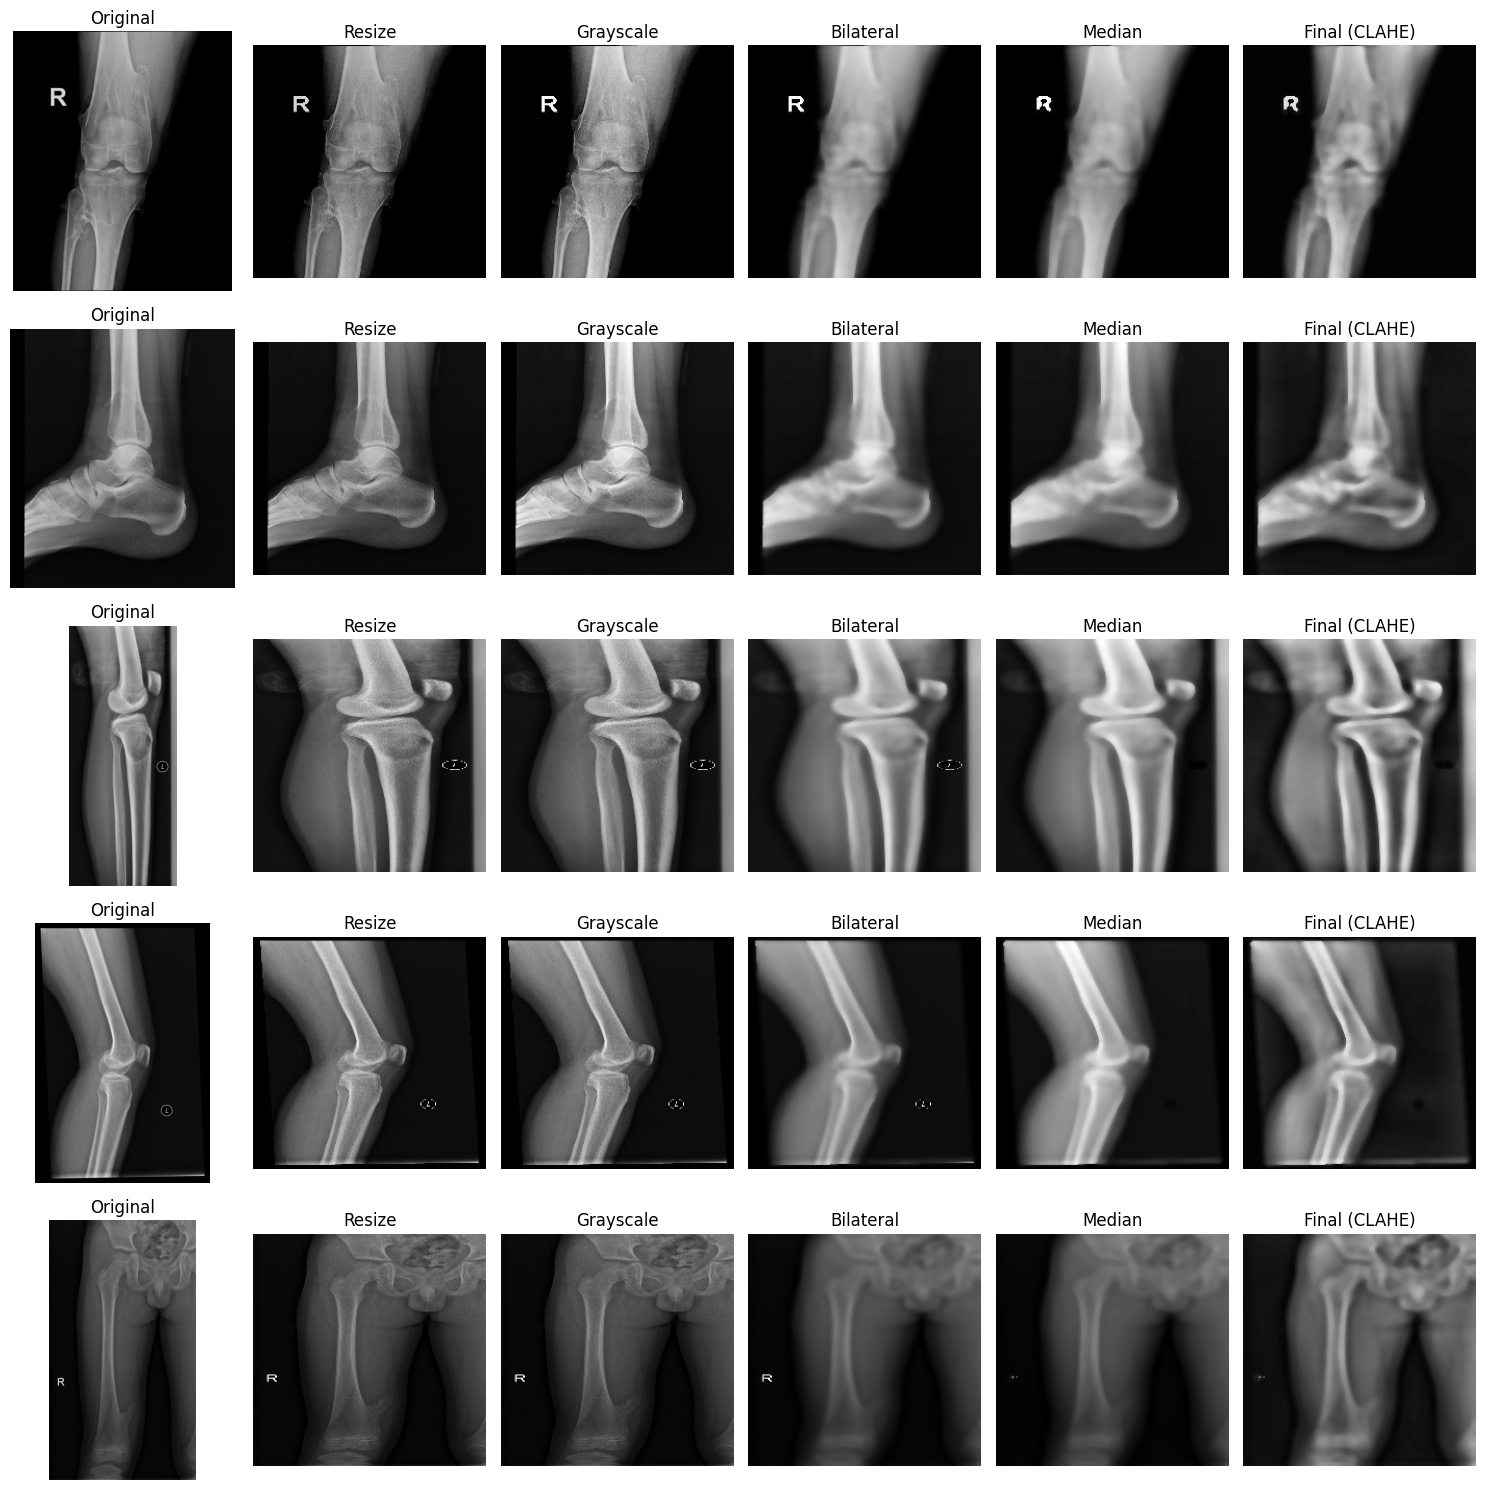


Batch info:
Train: 61
Val  : 8
Test : 8


I0000 00:00:1781255059.167704      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1781255059.174060      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50


...

 7/61 ━━━━━━━━━━━━━━━━━━━━ 50s 940ms/step - accuracy: 0.2826 - loss: 1.5439

2026-06-12 09:05:04.292131: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-12 09:05:04.448464: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-12 09:05:04.584823: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3429 - loss: 1.4069

2026-06-12 09:06:32.862108: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-12 09:06:32.999445: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


61/61 ━━━━━━━━━━━━━━━━━━━━ 132s 2s/step - accuracy: 0.3436 - loss: 1.4053 - val_accuracy: 0.2407 - val_loss: 1.3981 - learning_rate: 5.0000e-05
Epoch 2/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - accuracy: 0.4507 - loss: 1.0991 - val_accuracy: 0.3402 - val_loss: 1.2755 - learning_rate: 5.0000e-05
Epoch 3/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 61s 1s/step - accuracy: 0.4823 - loss: 1.0172 - val_accuracy: 0.4398 - val_loss: 1.1645 - learning_rate: 5.0000e-05
Epoch 4/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 65s 1s/step - accuracy: 0.5156 - loss: 0.9759 - val_accuracy: 0.4813 - val_loss: 1.0995 - learning_rate: 5.0000e-05
Epoch 5/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 65s 1s/step - accuracy: 0.5384 - loss: 0.9275 - val_accuracy: 0.4772 - val_loss: 1.0339 - learning_rate: 5.0000e-05
Epoch 6/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - accuracy: 0.5647 - loss: 0.9061 - val_accuracy: 0.5145 - val_loss: 0.9691 - learning_rate: 5.0000e-05
Epoch 7/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 62s 1s/step - accuracy: 0.5521 - loss: 0.9057 - 

In [6]:
# =========================================
# FINAL PIPELINE: PREVIEW + AUGMENT + OPTIMIZED MODEL
# =========================================

import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import math

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.metrics import classification_report, accuracy_score
from sklearn.utils.class_weight import compute_class_weight

print("Mulai pipeline FINAL...")

# =========================================
# PREPROCESS FUNCTION (FILTER_CLAHE)
# =========================================

def preprocess_image(img):
    img = cv2.resize(img, (224,224))
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    bilateral = cv2.bilateralFilter(gray, 9, 75, 75)
    median = cv2.medianBlur(bilateral, 5)

    clahe = cv2.createCLAHE(2.0, (8,8))
    processed = clahe.apply(median)

    processed = cv2.cvtColor(processed, cv2.COLOR_GRAY2RGB)
    return processed / 255.0


# =========================================
# VISUALISASI PREPROCESS (DEBUG)
# =========================================

def show_preprocessing_sample(df, n=3):
    print("\nMenampilkan semua tahap preprocessing...")

    fig, axes = plt.subplots(n, 6, figsize=(15, 3*n))

    for i in range(n):
        row = df.sample(1).iloc[0]
        img = cv2.imread(row["image_path"])

        if img is None:
            continue

        # STEP 1
        resized = cv2.resize(img, (224,224))

        # STEP 2
        gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)

        # STEP 3
        bilateral = cv2.bilateralFilter(gray, 9, 75, 75)

        # STEP 4
        median = cv2.medianBlur(bilateral, 5)

        # STEP 5
        clahe = cv2.createCLAHE(2.0, (8,8))
        clahe_img = clahe.apply(median)

        # STEP 6
        final = cv2.cvtColor(clahe_img, cv2.COLOR_GRAY2RGB) / 255.0

        images = [
            cv2.cvtColor(img, cv2.COLOR_BGR2RGB),
            resized,
            gray,
            bilateral,
            median,
            final
        ]

        titles = [
            "Original",
            "Resize",
            "Grayscale",
            "Bilateral",
            "Median",
            "Final (CLAHE)"
        ]

        for j in range(6):
            axes[i,j].imshow(images[j], cmap="gray" if j>=2 else None)
            axes[i,j].set_title(titles[j])
            axes[i,j].axis("off")

    plt.tight_layout()
    plt.show()
    
# =========================================
# GENERATOR (AUGMENT LEBIH KUAT)
# =========================================

class CustomGenerator(tf.keras.utils.Sequence):
    def __init__(self, df, batch_size, shuffle=True):
        self.df = df.reset_index(drop=True)
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.indexes = np.arange(len(df))
        self.labels = sorted(df["label"].unique())
        self.label_map = {k:i for i,k in enumerate(self.labels)}

    def __len__(self):
        return math.ceil(len(self.df) / self.batch_size)

    def __getitem__(self, idx):
        batch_idx = self.indexes[idx*self.batch_size:(idx+1)*self.batch_size]
        batch = self.df.iloc[batch_idx]

        X, y = [], []

        for _, row in batch.iterrows():
            img = cv2.imread(row["image_path"])
            if img is None:
                continue

            img = preprocess_image(img)

            # =================================
            # AUGMENTASI LEBIH KUAT (TRAIN ONLY)
            # =================================
            if self.shuffle:
                if np.random.rand() < 0.5:
                    img = np.fliplr(img)

                if np.random.rand() < 0.3:
                    img = np.rot90(img)

                if np.random.rand() < 0.3:
                    noise = np.random.normal(0, 0.02, img.shape)
                    img = np.clip(img + noise, 0, 1)

                if np.random.rand() < 0.3:
                    img = np.clip(img * (0.8 + 0.4*np.random.rand()), 0, 1)

            X.append(img)
            y.append(self.label_map[row["label"]])

        return np.array(X), tf.keras.utils.to_categorical(y, num_classes=len(self.labels))

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indexes)


# =========================================
# MODEL OPTIMIZED
# =========================================

def build_model(num_classes):
    base_model = MobileNetV2(weights="imagenet", include_top=False, input_shape=(224,224,3))

    # freeze lebih banyak
    for layer in base_model.layers[:-5]:
        layer.trainable = False

    for layer in base_model.layers[-5:]:
        layer.trainable = True

    x = base_model.output
    x = GlobalAveragePooling2D()(x)

    x = Dense(128, activation="relu")(x)
    x = Dropout(0.6)(x)

    output = Dense(num_classes, activation="softmax")(x)

    model = Model(inputs=base_model.input, outputs=output)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=5e-5),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


# =========================================
# CLASS WEIGHT
# =========================================

labels = train_df["label"]

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)

class_weight_dict = dict(zip(range(len(class_weights)), class_weights))

print("Class weight:", class_weight_dict)


# =========================================
# CALLBACK
# =========================================

early_stop = EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=1)


# =========================================
# PREVIEW HASIL PREPROCESS
# =========================================

show_preprocessing_sample(train_df, n=5)


# =========================================
# GENERATOR
# =========================================

train_gen = CustomGenerator(train_df, 32, shuffle=True)
val_gen = CustomGenerator(val_df, 32, shuffle=False)
test_gen = CustomGenerator(test_df, 32, shuffle=False)

print("\nBatch info:")
print("Train:", len(train_gen))
print("Val  :", len(val_gen))
print("Test :", len(test_gen))


# =========================================
# TRAINING FINAL
# =========================================

model = build_model(num_classes=len(train_gen.labels))

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=50,
    class_weight=class_weight_dict,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)


# =========================================
# EVALUASI
# =========================================

y_pred, y_true = [], []

for i in range(len(test_gen)):
    X, y = test_gen[i]

    if len(X) == 0:
        continue

    pred = model.predict(X, verbose=0)

    y_pred.extend(np.argmax(pred, axis=1))
    y_true.extend(np.argmax(y, axis=1))

print("\nAccuracy:", accuracy_score(y_true, y_pred))
print(classification_report(y_true, y_pred))

Mulai pipeline FINAL...
Class weight: {0: np.float64(0.7422839506172839), 1: np.float64(3.4855072463768115), 2: np.float64(0.7321156773211568)}

Menampilkan semua tahap preprocessing...


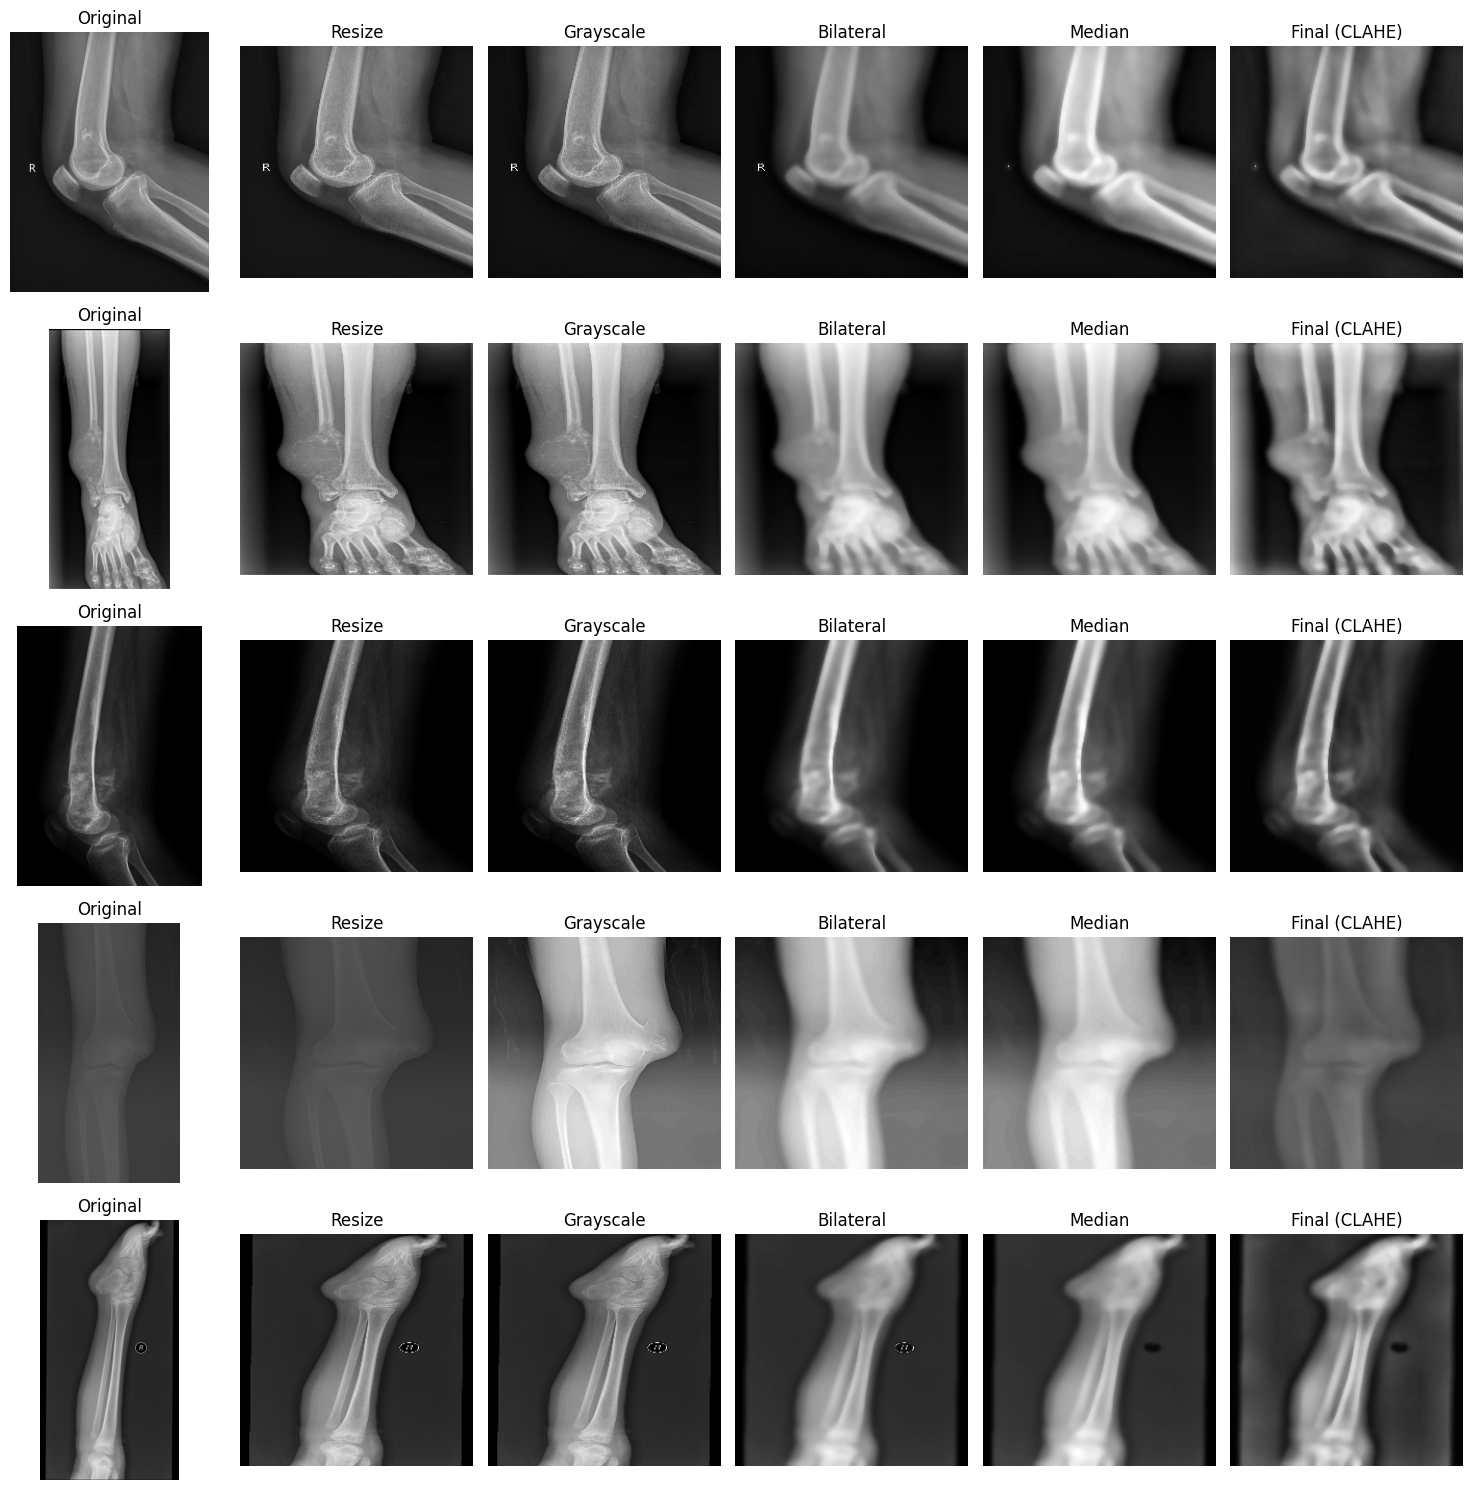


Batch info:
Train: 61
Val  : 8
Test : 8


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 78s 1s/step - accuracy: 0.3856 - loss: 1.3179 - val_accuracy: 0.4315 - val_loss: 1.0955 - learning_rate: 5.0000e-05
Epoch 2/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 58s 953ms/step - accuracy: 0.4617 - loss: 1.0977 - val_accuracy: 0.5394 - val_loss: 1.0061 - learning_rate: 5.0000e-05
Epoch 3/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 57s 933ms/step - accuracy: 0.5114 - loss: 0.9581 - val_accuracy: 0.5560 - val_loss: 0.9813 - learning_rate: 5.0000e-05
Epoch 4/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 53s 874ms/step - accuracy: 0.5500 - loss: 0.8998 - val_accuracy: 0.5768 - val_loss: 0.9630 - learning_rate: 5.0000e-05
Epoch 5/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 51s 831ms/step - accuracy: 0.5976 - loss: 0.8425 - val_accuracy: 0.5934 - val_loss: 0.9027 - learning_rate: 5.0000e-05
Epoch 6/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 52s 857ms/step - accuracy: 0.5822 - loss: 0.8403 - val_accuracy: 0.6390 - val_loss: 0.8664 - learning_rate: 5.0000e-05
Epoch 7/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 52s 850ms/step - accura

In [7]:
# =========================================
# FINAL PIPELINE: PREVIEW + AUGMENT + OPTIMIZED MODEL
# =========================================

import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import math

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.metrics import classification_report, accuracy_score
from sklearn.utils.class_weight import compute_class_weight

print("Mulai pipeline FINAL...")

# =========================================
# PREPROCESS FUNCTION (FILTER_CLAHE)
# =========================================

def preprocess_image(img):
    img = cv2.resize(img, (224,224))
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    bilateral = cv2.bilateralFilter(gray, 9, 75, 75)
    median = cv2.medianBlur(bilateral, 5)

    clahe = cv2.createCLAHE(2.0, (8,8))
    processed = clahe.apply(median)

    processed = cv2.cvtColor(processed, cv2.COLOR_GRAY2RGB)
    return processed / 255.0


# =========================================
# VISUALISASI PREPROCESS (DEBUG)
# =========================================

def show_preprocessing_sample(df, n=3):
    print("\nMenampilkan semua tahap preprocessing...")

    fig, axes = plt.subplots(n, 6, figsize=(15, 3*n))

    for i in range(n):
        row = df.sample(1).iloc[0]
        img = cv2.imread(row["image_path"])

        if img is None:
            continue

        # STEP 1
        resized = cv2.resize(img, (224,224))

        # STEP 2
        gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)

        # STEP 3
        bilateral = cv2.bilateralFilter(gray, 9, 75, 75)

        # STEP 4
        median = cv2.medianBlur(bilateral, 5)

        # STEP 5
        clahe = cv2.createCLAHE(2.0, (8,8))
        clahe_img = clahe.apply(median)

        # STEP 6
        final = cv2.cvtColor(clahe_img, cv2.COLOR_GRAY2RGB) / 255.0

        images = [
            cv2.cvtColor(img, cv2.COLOR_BGR2RGB),
            resized,
            gray,
            bilateral,
            median,
            final
        ]

        titles = [
            "Original",
            "Resize",
            "Grayscale",
            "Bilateral",
            "Median",
            "Final (CLAHE)"
        ]

        for j in range(6):
            axes[i,j].imshow(images[j], cmap="gray" if j>=2 else None)
            axes[i,j].set_title(titles[j])
            axes[i,j].axis("off")

    plt.tight_layout()
    plt.show()
    
# =========================================
# GENERATOR (AUGMENT LEBIH KUAT)
# =========================================

class CustomGenerator(tf.keras.utils.Sequence):
    def __init__(self, df, batch_size, shuffle=True):
        self.df = df.reset_index(drop=True)
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.indexes = np.arange(len(df))
        self.labels = sorted(df["label"].unique())
        self.label_map = {k:i for i,k in enumerate(self.labels)}

    def __len__(self):
        return math.ceil(len(self.df) / self.batch_size)

    def __getitem__(self, idx):
        batch_idx = self.indexes[idx*self.batch_size:(idx+1)*self.batch_size]
        batch = self.df.iloc[batch_idx]

        X, y = [], []

        for _, row in batch.iterrows():
            img = cv2.imread(row["image_path"])
            if img is None:
                continue

            img = preprocess_image(img)

            # =================================
            # AUGMENTASI LEBIH KUAT (TRAIN ONLY)
            # =================================
            if self.shuffle:
                if np.random.rand() < 0.5:
                    img = np.fliplr(img)

                if np.random.rand() < 0.3:
                    img = np.rot90(img)

                if np.random.rand() < 0.3:
                    noise = np.random.normal(0, 0.02, img.shape)
                    img = np.clip(img + noise, 0, 1)

                if np.random.rand() < 0.3:
                    img = np.clip(img * (0.8 + 0.4*np.random.rand()), 0, 1)

            X.append(img)
            y.append(self.label_map[row["label"]])

        return np.array(X), tf.keras.utils.to_categorical(y, num_classes=len(self.labels))

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indexes)


# =========================================
# MODEL OPTIMIZED
# =========================================

def build_model(num_classes):
    base_model = MobileNetV2(weights="imagenet", include_top=False, input_shape=(224,224,3))

    # freeze lebih banyak
    for layer in base_model.layers[:-5]:
        layer.trainable = False

    for layer in base_model.layers[:-30]:
        layer.trainable = False
    for layer in base_model.layers[-30:]:
        layer.trainable = True

    x = base_model.output
    x = GlobalAveragePooling2D()(x)

    x = Dense(128, activation="relu")(x)
    x = Dropout(0.6)(x)

    output = Dense(num_classes, activation="softmax")(x)

    model = Model(inputs=base_model.input, outputs=output)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=5e-5),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


# =========================================
# CLASS WEIGHT
# =========================================

labels = train_df["label"]

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)

class_weight_dict = dict(zip(range(len(class_weights)), class_weights))

print("Class weight:", class_weight_dict)


# =========================================
# CALLBACK
# =========================================

early_stop = EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=1)


# =========================================
# PREVIEW HASIL PREPROCESS
# =========================================

show_preprocessing_sample(train_df, n=5)


# =========================================
# GENERATOR
# =========================================

train_gen = CustomGenerator(train_df, 32, shuffle=True)
val_gen = CustomGenerator(val_df, 32, shuffle=False)
test_gen = CustomGenerator(test_df, 32, shuffle=False)

print("\nBatch info:")
print("Train:", len(train_gen))
print("Val  :", len(val_gen))
print("Test :", len(test_gen))


# =========================================
# TRAINING FINAL
# =========================================

model = build_model(num_classes=len(train_gen.labels))

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=50,
    class_weight=class_weight_dict,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)


# =========================================
# EVALUASI
# =========================================

y_pred, y_true = [], []

for i in range(len(test_gen)):
    X, y = test_gen[i]

    if len(X) == 0:
        continue

    pred = model.predict(X, verbose=0)

    y_pred.extend(np.argmax(pred, axis=1))
    y_true.extend(np.argmax(y, axis=1))

print("\nAccuracy:", accuracy_score(y_true, y_pred))
print(classification_report(y_true, y_pred))


FULL PREDICTION TABLE — ALL SAMPLES
       actual  predicted  confidence  correct  prob_benign  prob_malignant  \
0      benign     normal    0.370882    False     0.317502        0.311615   
1      benign  malignant    0.382442    False     0.380204        0.382442   
2      normal     benign    0.384830    False     0.384830        0.248670   
3      benign     normal    0.386485    False     0.336471        0.277044   
4      normal     benign    0.392333    False     0.392333        0.326470   
5      benign     normal    0.403978    False     0.290652        0.305370   
6      normal     normal    0.405144     True     0.380856        0.214000   
7      normal     normal    0.406654     True     0.378590        0.214756   
8      normal     benign    0.407361    False     0.407361        0.278419   
9      benign     normal    0.407419    False     0.289193        0.303388   
10     benign  malignant    0.408842    False     0.258361        0.408842   
11  malignant  malignant   

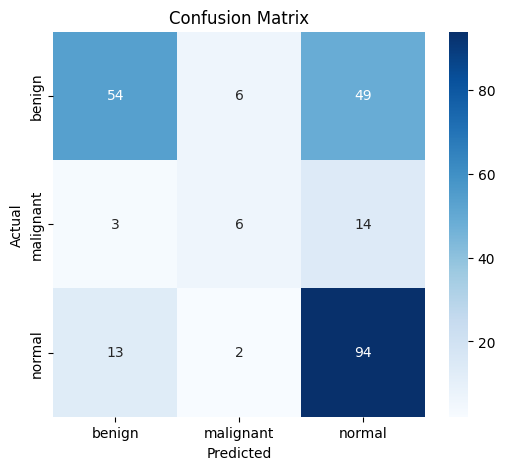

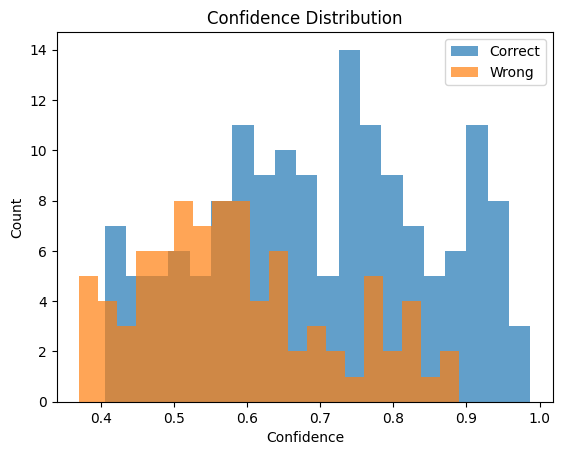

In [8]:
# =========================================
# FULL PREDICTION TABLE + ANALYSIS
# =========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("\n" + "="*70)
print("FULL PREDICTION TABLE — ALL SAMPLES")
print("="*70)

# =========================================
# LABEL MAPPING
# =========================================

label_names = train_gen.labels
idx_to_label = {i:label for i,label in enumerate(label_names)}

# =========================================
# BUILD PREDICTION TABLE
# =========================================

records = []

for i in range(len(test_gen)):
    X, y = test_gen[i]

    if len(X) == 0:
        continue

    preds = model.predict(X, verbose=0)

    for j in range(len(X)):
        true_idx = np.argmax(y[j])
        pred_idx = np.argmax(preds[j])

        record = {
            "image_path": test_df.iloc[i*test_gen.batch_size + j]["image_path"],
            "actual": idx_to_label[true_idx],
            "predicted": idx_to_label[pred_idx],
            "confidence": float(np.max(preds[j])),
            "correct": true_idx == pred_idx
        }

        # simpan probabilitas tiap kelas
        for k in range(len(label_names)):
            record[f"prob_{idx_to_label[k]}"] = float(preds[j][k])

        records.append(record)

pred_df = pd.DataFrame(records)

# =========================================
# SORT BY UNCERTAINTY (LOW CONFIDENCE)
# =========================================

pred_df = pred_df.sort_values("confidence", ascending=True).reset_index(drop=True)

# =========================================
# PRINT TABLE
# =========================================

display_df = pred_df[[
    "actual", "predicted", "confidence", "correct"
] + [col for col in pred_df.columns if "prob_" in col]]

print(display_df.head(30))  # tampilkan 30 teratas (paling susah)

# =========================================
# SUMMARY
# =========================================

acc = accuracy_score(pred_df["actual"], pred_df["predicted"])

print("\n" + "-"*50)
print(f"Total data     : {len(pred_df)}")
print(f"Accuracy       : {acc:.4f}")
print(f"Correct        : {pred_df['correct'].sum()}")
print(f"Wrong          : {(~pred_df['correct']).sum()}")

print("\nClassification Report:")
print(classification_report(pred_df["actual"], pred_df["predicted"]))

# =========================================
# CONFUSION MATRIX
# =========================================

plt.figure(figsize=(6,5))
cm = confusion_matrix(pred_df["actual"], pred_df["predicted"], labels=label_names)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_names,
            yticklabels=label_names)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# =========================================
# CONFIDENCE DISTRIBUTION
# =========================================

plt.figure()
plt.hist(pred_df[pred_df["correct"]]["confidence"], bins=20, alpha=0.7, label="Correct")
plt.hist(pred_df[~pred_df["correct"]]["confidence"], bins=20, alpha=0.7, label="Wrong")
plt.legend()
plt.title("Confidence Distribution")
plt.xlabel("Confidence")
plt.ylabel("Count")
plt.show()